In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import glob

import astropy.units as u
from astropy.coordinates import SpectralCoord,SkyCoord

from irispy.io import read_files

import cmasher as cmr

In [2]:
import scienceplots
plt.rcParams.update({'font.size': 16})
plt.style.use(['bright'])
plt.rcParams['font.family'] = 'Atkinson Hyperlegible Next'

from sunpy.visualization.colormaps import color_tables as ct
sji1400cm = ct.iris_sji_color_table('1400')
sji1400cm.set_bad('black')

load all IRIS spectral raster FITS files:

In [3]:
fits_dir = '/Users/willashfield/indirect_imaging/feb3/iris_l2_20260203_135710_3448103329_raster/'
raster_files = sorted(glob.glob(fits_dir + '*.fits'))

raster = read_files(raster_files, memmap=False)

In [4]:
# only want the Si IV 1403 line
siiv = raster['Si IV 1403']

print(siiv)

SpectrogramCubeSequence
-----------------------
Time Range: ['2026-02-03 13:57:10.986' '2026-02-03 15:02:45.452']
Pixel Dimensions: (<Quantity 432. pix>, <Quantity 8. pix>, <Quantity 204. pix>, <Quantity 247. pix>)
Longitude range: [-201.44224531 -184.19365661] arcsec
Latitude range: [298.22135769 366.78400206] arcsec
Spectral range: [1.40015735e-07 1.40641559e-07] m
Data unit: DN_IRIS_FUV


/opt/homebrew/Caskroom/miniforge/base/envs/ribbon/lib/python3.13/site-packages/ndcube/ndcube_sequence.py:50: NDCubeDeprecationWarning: Replaced by ndcube.NDCubeSequence.shape
  warn_deprecated("Replaced by ndcube.NDCubeSequence.shape")


In [5]:
siiv[118].time # find the time we want. 

<Time object: scale='utc' format='isot' value=['2026-02-03T14:15:06.281' '2026-02-03T14:15:07.577'
 '2026-02-03T14:15:08.671' '2026-02-03T14:15:09.796'
 '2026-02-03T14:15:10.890' '2026-02-03T14:15:11.984'
 '2026-02-03T14:15:13.109' '2026-02-03T14:15:14.202']>

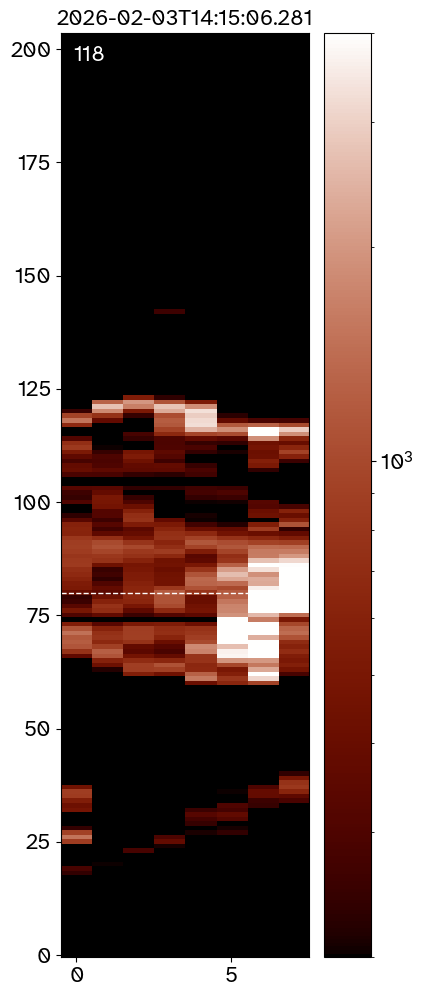

In [6]:
it = 118 

# we are only instersted in the Si IV 1403 line, so crop to that wavelength range (roughly here)
wvl_min = [SpectralCoord(1401.5, unit=u.Angstrom), None]
wvl_max = [SpectralCoord(1405.0, unit=u.Angstrom), None]

siiv_spec = siiv[it].crop(wvl_min, wvl_max) # define by time and wavelength range.
siiv_raster = siiv_spec.data.sum(axis=2) # summ along wavelength axis to get a 2D raster image (spatial x spatial)

fig, ax = plt.subplots(figsize=(4,12))
im = ax.imshow(siiv_raster.T, origin='lower', aspect = 'auto', norm=LogNorm(vmin=200.0, vmax=4e3), cmap=sji1400cm)
ax.set_title(siiv[it].time[0],fontsize=16)

plt.colorbar(im, ax=ax)
ax.text(0.05, 0.97, f'{it}', color='w', fontsize=16, transform=ax.transAxes)

# plot a horizontal line at y=80 -- same pixel for each slit location as it scans. 
iy = 80 
ax.axhline(iy, color='w', ls='--', lw=1)

for the pixel (iy) above, plot all of the spectra (8 total) for each raster scan:

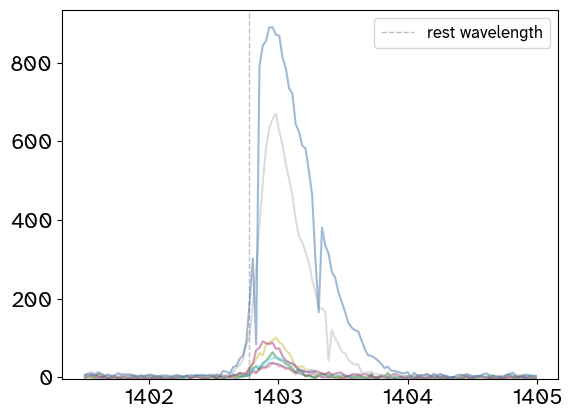

In [7]:
for s in siiv_spec:
    plt.plot(s.spectral_axis.to(u.Angstrom), s[iy].data, alpha=0.5)

plt.ylim(bottom=-5)

rest_wvl = 1402.77 
plt.axvline(rest_wvl, color='k', ls='--', lw=1, alpha=0.25, label='rest wavelength')

plt.legend(fontsize=12)

pick the strongest line:

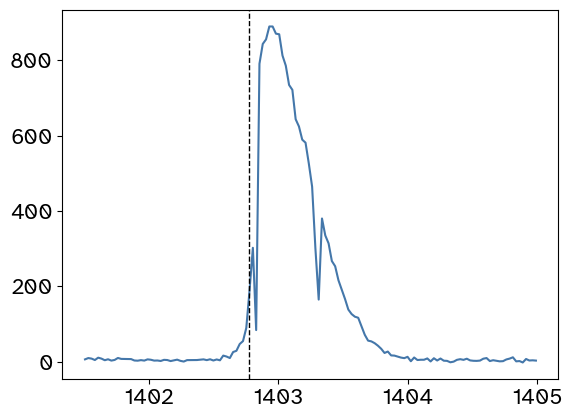

In [8]:
plt.plot(siiv_spec.spectral_axis.to(u.Angstrom), siiv_spec[7,iy].data)
plt.axvline(rest_wvl, color='k', ls='--', lw=1)

In [9]:
# find peak wavelength of the line at this slit position.
peak_wvl = siiv_spec.spectral_axis[np.argmax(siiv_spec[4,iy].data)].to(u.Angstrom)
rest_wvl = SpectralCoord(1402.77, unit=u.Angstrom)
print(peak_wvl)

print('Velocity:', (peak_wvl - rest_wvl)/rest_wvl * 3e5, 'km/s')

1402.9811878697335 Angstrom
Velocity: 45.16518097767734 km/s


We can also plot the raster image in terms of its HPC location:

Text(0.5, 1.0, '2026-02-03T14:15:06.281')

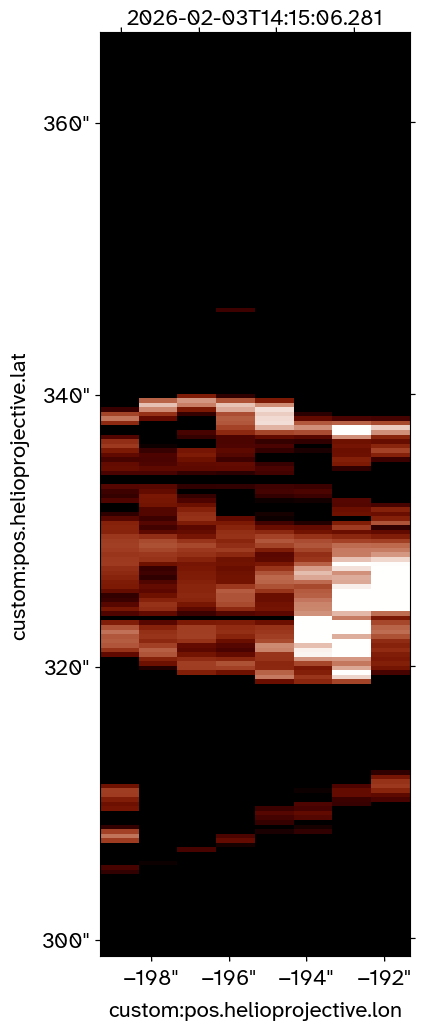

In [10]:
fig = plt.figure(figsize=(4,12))
ax = fig.add_subplot(111, projection=siiv_spec.wcs,slices=(0,'y','x'))

im = ax.imshow(siiv_raster.T, origin='lower', aspect = 'auto', norm=LogNorm(vmin=200.0, vmax=4e3), cmap=sji1400cm)
ax.set_title(siiv[it].time[0],fontsize=16)

or, **even better**, we can make a sunpy map:

INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]


For frame 'heliographic_stonyhurst' the following metadata is missing: hglt_obs,hgln_obs
For frame 'heliographic_carrington' the following metadata is missing: crln_obs,crlt_obs
 [sunpy.map.mapbase]


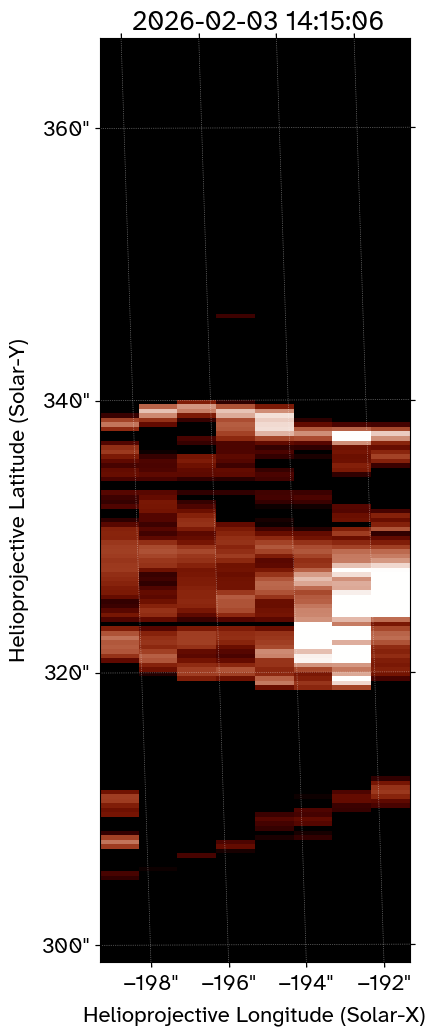

In [11]:
import sunpy.map

it = 118
siiv_spec   = siiv[it].crop(wvl_min, wvl_max)
siiv_raster = siiv_spec.data.sum(axis=2)    


cel = siiv_spec.wcs.low_level_wcs._wcs.celestial.swapaxes(0, 1)
hdr = cel.to_header()


oh = siiv_spec.meta.original_header
hdr['DATE-OBS'] = oh['DATE_OBS']
hdr['DSUN_OBS'] = oh['DSUN_OBS']
hdr['telescop'] = 'IRIS'
hdr['instrume'] = 'SPEC'

siiv_map = sunpy.map.Map(siiv_raster.T, hdr)      # .T to match the swapped WCS / your figure

#siiv_map.peek(norm=LogNorm(vmin=200.0, vmax=4e3), cmap=sji1400cm)

fig = plt.figure(figsize=(4,12))
ax = fig.add_subplot(projection=siiv_map)
siiv_map.plot(axes=ax, norm=LogNorm(vmin=200.0, vmax=4e3), cmap=sji1400cm, aspect='auto')

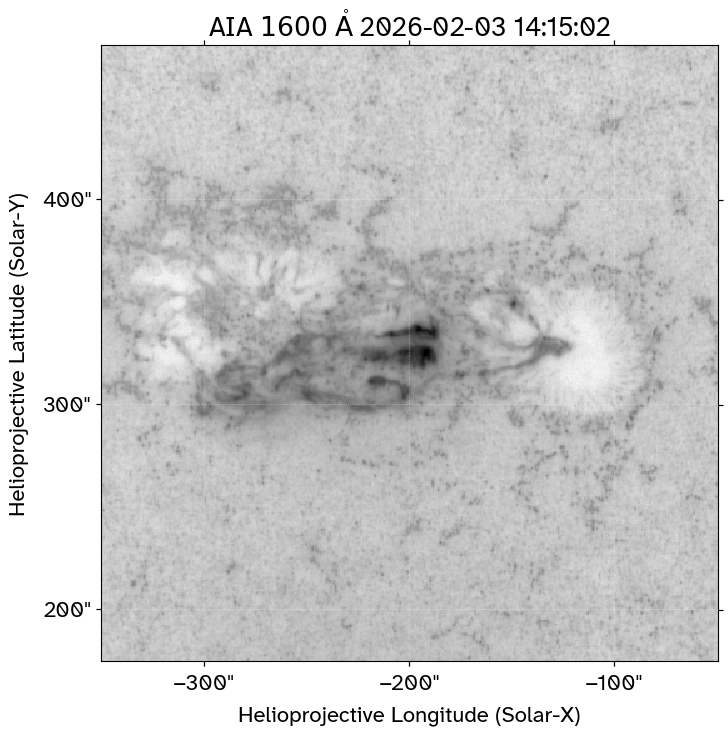

In [12]:
aia_fn = '/Users/willashfield/indirect_imaging/feb3/aia.lev1.1600A_2026_02_03T14_15_02.13Z.image_lev1.fits'

ref_map = sunpy.map.Map(aia_fn)

XL, XR, YB, YT = -350, -50, 175, 475 # larger FOV to capture more of the ribbons


xlims_world = [XL, XR]*u.arcsec #small
ylims_world = [YB, YT]*u.arcsec

lb = SkyCoord(xlims_world[0],ylims_world[0],frame=ref_map.coordinate_frame)
tr = SkyCoord(xlims_world[1],ylims_world[1],frame=ref_map.coordinate_frame)

amap = ref_map.submap(lb, top_right=tr)

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(projection=amap)
amap.plot(axes=ax,norm=LogNorm(),cmap=cmr.neutral_r)

In [ ]:
def raster_reproject(raster_map, ref_aia_map):

    # WCS axis 1 = x (raster-step), axis 2 = y (along-slit)
    ratio_x = (ref_aia_map.scale[0] / raster_map.scale[0]).decompose().value
    ratio_y = (ref_aia_map.scale[1] / raster_map.scale[1]).decompose().value
    ratio = np.array([ratio_x, ratio_y])

    new_wcs = ref_aia_map.wcs.deepcopy()
    new_wcs.wcs.cdelt = new_wcs.wcs.cdelt / ratio

    # preserve pixel alignment with rescaling. 
    new_wcs.wcs.crpix = (ref_aia_map.wcs.wcs.crpix - 0.5) * ratio + 0.5
    new_wcs.wcs.dateobs = raster_map.date.iso

    shape_out = (
        int(np.round(ref_aia_map.data.shape[0] * ratio_y)),  # rows -> y
        int(np.round(ref_aia_map.data.shape[1] * ratio_x)),  # cols -> x
    )

    return raster_map.reproject_to(new_wcs, shape_out=shape_out)

INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]


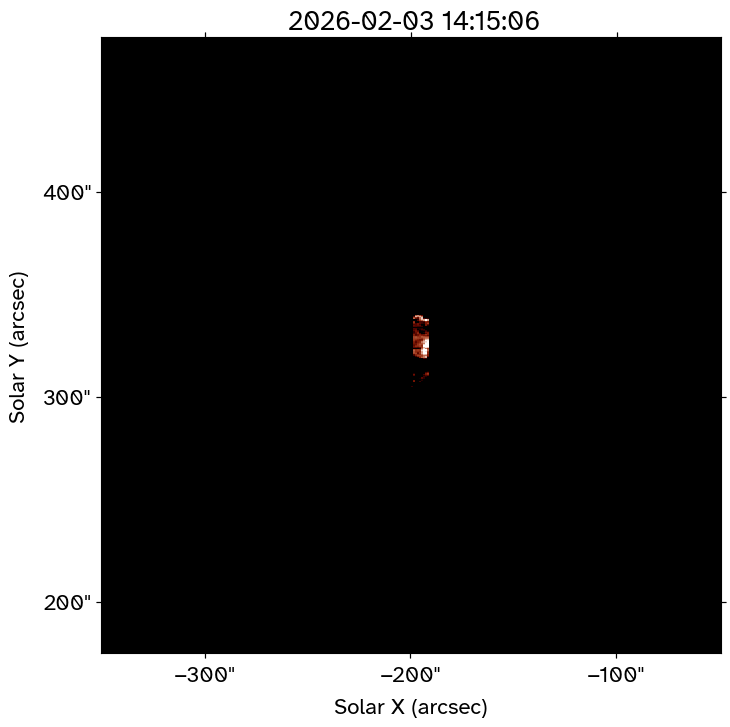

In [14]:
siiv_reproj = raster_reproject(siiv_map, amap)

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(projection=siiv_reproj)
siiv_reproj.plot(axes=ax, norm=LogNorm(vmin=200.0, vmax=4e3), cmap=sji1400cm, aspect='auto')
ax.coords.grid(False)
ax.set_xlabel('Solar X (arcsec)')
ax.set_ylabel('Solar Y (arcsec)')